# HOTEL BOOKING DATA CLEANING & EDA PROJECT

## 1. Project Objective
* This project focuses on cleaning and preparing the hotel booking dataset for further exploratory data analysis. The main goal is to inspect data quality issues, such as missing values, duplicate records, inconsistent data types, and logically invalid observations, to build a more reliable dataset for analysis.

## 2. Completed Steps
* Loaded the dataset
* Reviewed dataset shape and structure
* Examined data types
* Analyzed missing values
* Checked duplicate rows
* Compared key metrics before and after removing duplicates
* Cleaned selected columns
* Created a new feature: total_guests
* Removed logically invalid records
* Reviewed possible outliers and invalid values

## 3. Import Libraries

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

## 4. Load the Dataset

In [2]:
print(os.getcwd())

C:\Users\HANDE\Desktop\GitHub\04_Hotel-Booking_PythonDataCleaning_EDAProject\notebooks


In [3]:
df = pd.read_csv("../data/raw/hotel_bookings.csv")

## 5. Initial Data Inspection

In [4]:
# Display the first 5 rows
pd.set_option("display.max_columns", None)
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [5]:
# Check dataset shape
df.shape 

(119390, 32)

In [6]:
# Show general information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [7]:
# Summary of numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


In [8]:
# Summary of categorical columns
df.describe(include=["object"]).T

,count,unique,top,freq
hotel,119390,2,City Hotel,79330
arrival_date_month,119390,12,August,13877
meal,119390,5,BB,92310
country,118902,177,PRT,48590
market_segment,119390,8,Online TA,56477
distribution_channel,119390,5,TA/TO,97870
reserved_room_type,119390,10,A,85994
assigned_room_type,119390,12,A,74053
deposit_type,119390,3,No Deposit,104641
customer_type,119390,4,Transient,89613


In [9]:
# View missing values
missing_value = df.isnull().sum()
missing_percentage = (missing_value /len(df))*100
missing_summary = pd.DataFrame({"missing_count":missing_value,
                            "missing_percentage":missing_percentage}).sort_values(by="missing_percentage", ascending = False)
missing_summary

,missing_count,missing_percentage
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350
reserved_room_type,0,0.000000
assigned_room_type,0,0.000000
booking_changes,0,0.000000
deposit_type,0,0.000000
hotel,0,0.000000
previous_cancellations,0,0.000000


* If the missing rate is close to 0%, it is usually a minor issue.
* If the missing rate is around 10–20%, it requires attention.
* If the missing rate is above 90%, dropping the column may be considered depending on its importance.

In [10]:
# Duplicate rows
df.duplicated().sum() 

np.int64(31994)

In [11]:
# View duplicate records
duplicate_rows = df[df.duplicated(keep = False)]
duplicate_rows.head(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
21,Resort Hotel,0,72,2015,July,27,1,2,4,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,A,A,1,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07
22,Resort Hotel,0,72,2015,July,27,1,2,4,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,A,A,1,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07
39,Resort Hotel,0,70,2015,July,27,2,2,3,2,0.0,0,HB,ROU,Direct,Direct,0,0,0,E,E,0,No Deposit,250.0,NaN,0,Transient,137.00,0,1,Check-Out,2015-07-07
43,Resort Hotel,0,70,2015,July,27,2,2,3,2,0.0,0,HB,ROU,Direct,Direct,0,0,0,E,E,0,No Deposit,250.0,NaN,0,Transient,137.00,0,1,Check-Out,2015-07-07
132,Resort Hotel,1,5,2015,July,28,5,1,0,2,0.0,0,BB,PRT,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,240.0,NaN,0,Transient,97.00,0,0,Canceled,2015-07-01
138,Resort Hotel,1,5,2015,July,28,5,1,0,2,0.0,0,BB,PRT,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,240.0,NaN,0,Transient,97.00,0,0,Canceled,2015-07-01
198,Resort Hotel,0,0,2015,July,28,7,0,1,1,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,109.80,0,3,Check-Out,2015-07-08
200,Resort Hotel,0,0,2015,July,28,7,0,1,1,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,109.80,0,3,Check-Out,2015-07-08


In [12]:
# Analyze duplicate records
print("Original shape:", df.shape)
print("Original cancellation rate:", df["is_canceled"].mean())
print("Original average ADR:", df["adr"].mean())

df_no_dup = df.drop_duplicates()

print("No-duplicate shape:", df_no_dup.shape)
print("No-duplicate cancellation rate:", df_no_dup["is_canceled"].mean())
print("No-duplicate average ADR:", df_no_dup["adr"].mean())

Original shape: (119390, 32)
Original cancellation rate: 0.37041628277075134
Original average ADR: 101.83112153446687
No-duplicate shape: (87396, 32)
No-duplicate cancellation rate: 0.27489816467572886
No-duplicate average ADR: 106.33724644148474


In [13]:
duplicate_percentage = (df.duplicated().sum() / len(df)) * 100
duplicate_percentage

np.float64(26.797889270458164)

In [14]:
print(f"Duplicate row count: {df.duplicated().sum()}")
print(f"Duplicate percentage: {duplicate_percentage:.2f}%")

Duplicate row count: 31994
Duplicate percentage: 26.80%


## 6. Data Cleaning

### 6.1 Removing Duplicate Rows

In [15]:
# Create a cleaned copy of the dataset without duplicate rows
df_clean = df.drop_duplicates().copy()

In [16]:
# Check the shape of the cleaned dataset
df_clean.shape

(87396, 32)

### 6.2 Handling Missing Values

In [17]:
# View missing values for df_clean
missing_value_clean = df_clean.isnull().sum()
missing_percentage_clean = (missing_value_clean /len(df_clean))*100
missing_summary_clean = pd.DataFrame({"missing_count_clean":missing_value_clean,
                            "missing_percentage_clean":missing_percentage_clean}).sort_values(by="missing_percentage_clean", ascending = False)
missing_summary_clean

,missing_count_clean,missing_percentage_clean
company,82137,93.982562
agent,12193,13.951439
country,452,0.517186
children,4,0.004577
reserved_room_type,0,0.000000
assigned_room_type,0,0.000000
booking_changes,0,0.000000
deposit_type,0,0.000000
hotel,0,0.000000
previous_cancellations,0,0.000000


In [18]:
# Drop company column due to too many missing values
df_clean = df_clean.drop(columns = ["company"])
df_clean.shape

(87396, 31)

In [19]:
# Fill missing country values with Unknown
df_clean["country"] = df_clean["country"].fillna("Unknown")

In [20]:
# Inspect rows with missing children values
df_clean[df_clean["children"].isnull()]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
40600,City Hotel,1,2,2015,August,32,3,1,0,2,NaN,0,BB,PRT,Undefined,Undefined,0,0,0,B,B,0,No Deposit,NaN,0,Transient-Party,12.0,0,1,Canceled,2015-08-01
40667,City Hotel,1,1,2015,August,32,5,0,2,2,NaN,0,BB,PRT,Direct,Undefined,0,0,0,B,B,0,No Deposit,14.0,0,Transient-Party,12.0,0,1,Canceled,2015-08-04
40679,City Hotel,1,1,2015,August,32,5,0,2,3,NaN,0,BB,PRT,Undefined,Undefined,0,0,0,B,B,0,No Deposit,NaN,0,Transient-Party,18.0,0,2,Canceled,2015-08-04
41160,City Hotel,1,8,2015,August,33,13,2,5,2,NaN,0,BB,PRT,Online TA,Undefined,0,0,0,B,B,0,No Deposit,9.0,0,Transient-Party,76.5,0,1,Canceled,2015-08-09


In [21]:
# Check number of unique agents
df_clean["agent"].nunique()

333

In [22]:
# Fill missing children values with 0 and convert the children column to integer
df_clean["children"] = df_clean["children"].fillna(0).astype(int)

### 6.3 Data Type Adjustments

In [23]:
# Convert reservation status date to datetime
df_clean["reservation_status_date"] = pd.to_datetime(df_clean["reservation_status_date"])

### 6.4 Feature Engineering

In [24]:
# Create total guests column
df_clean["total_guests"] = df_clean["adults"] + df_clean["children"] + df_clean["babies"]

### 6.5 Removing Invalid Records

In [25]:
# Inspect rows with no adults, children, or babies
df_clean[(df_clean["adults"] == 0) & (df_clean["children"] == 0) & (df_clean["babies"] == 0)]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_guests
2224,Resort Hotel,0,1,2015,October,41,6,0,3,0,0,0,SC,PRT,Corporate,Corporate,0,0,0,A,I,1,No Deposit,NaN,0,Transient-Party,0.00,0,0,Check-Out,2015-10-06,0
2409,Resort Hotel,0,0,2015,October,42,12,0,0,0,0,0,SC,PRT,Corporate,Corporate,0,0,0,A,I,0,No Deposit,NaN,0,Transient,0.00,0,0,Check-Out,2015-10-12,0
3181,Resort Hotel,0,36,2015,November,47,20,1,2,0,0,0,SC,ESP,Groups,TA/TO,0,0,0,A,C,0,No Deposit,38.0,0,Transient-Party,0.00,0,0,Check-Out,2015-11-23,0
3684,Resort Hotel,0,165,2015,December,53,30,1,4,0,0,0,SC,PRT,Groups,TA/TO,0,0,0,A,A,1,No Deposit,308.0,122,Transient-Party,0.00,0,0,Check-Out,2016-01-04,0
3708,Resort Hotel,0,165,2015,December,53,30,2,4,0,0,0,SC,PRT,Groups,TA/TO,0,0,0,A,C,1,No Deposit,308.0,122,Transient-Party,0.00,0,0,Check-Out,2016-01-05,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115029,City Hotel,0,107,2017,June,26,27,0,3,0,0,0,BB,CHE,Online TA,TA/TO,0,0,0,A,A,1,No Deposit,7.0,0,Transient,100.80,0,0,Check-Out,2017-06-30,0
115091,City Hotel,0,1,2017,June,26,30,0,1,0,0,0,SC,PRT,Complementary,Direct,0,0,0,E,K,0,No Deposit,NaN,0,Transient,0.00,1,1,Check-Out,2017-07-01,0
116251,City Hotel,0,44,2017,July,28,15,1,1,0,0,0,SC,SWE,Online TA,TA/TO,0,0,0,A,K,2,No Deposit,425.0,0,Transient,73.80,0,0,Check-Out,2017-07-17,0
116534,City Hotel,0,2,2017,July,28,15,2,5,0,0,0,SC,RUS,Online TA,TA/TO,0,0,0,A,K,1,No Deposit,9.0,0,Transient-Party,22.86,0,1,Check-Out,2017-07-22,0


In [26]:
# Find records with zero guests
df_clean[df_clean["total_guests"] == 0].shape

(166, 32)

In [27]:
# Remove records with zero guests
df_clean = df_clean[df_clean["total_guests"] > 0]
df_clean.shape

(87230, 32)

In [28]:
# Confirm that no zero-guest records remain
df_clean[df_clean["total_guests"] == 0].shape

(0, 32)

### 6.6 Validating Numeric Columns

In [29]:
# Check negative values in numeric columns
(df_clean[["lead_time", "adr", "adults", "children", "babies", 
           "stays_in_weekend_nights", "stays_in_week_nights"]] < 0).sum()

lead_time                  0
adr                        1
adults                     0
children                   0
babies                     0
stays_in_weekend_nights    0
stays_in_week_nights       0
dtype: int64

In [30]:
# Review ADR distribution
df_clean["adr"].describe()

count    87230.000000
mean       106.518031
std         54.891227
min         -6.380000
25%         72.250000
50%         98.200000
75%        134.100000
max       5400.000000
Name: adr, dtype: float64

In [31]:
# Inspect records with negative ADR values
df_clean[df_clean["adr"] < 0]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_guests
14969,Resort Hotel,0,195,2017,March,10,5,4,6,2,0,0,BB,GBR,Groups,Direct,1,0,2,A,H,2,No Deposit,273.0,0,Transient-Party,-6.38,0,0,Check-Out,2017-03-15,2


In [32]:
# Remove negative ADR values
df_clean = df_clean[df_clean["adr"] >= 0]

In [33]:
# Confirm that no negative ADR values remain
(df_clean["adr"] < 0).sum()

np.int64(0)

In [34]:
# Check highest ADR values
df_clean["adr"].sort_values(ascending=False).head(10)

48515     5400.00
111403     510.00
15083      508.00
103912     451.50
13142      450.00
13391      437.00
39155      426.25
39568      402.00
39118      397.38
39517      392.00
Name: adr, dtype: float64

### 6.7 Additional Validation Checks

In [35]:
# Check room type differences
(df_clean["reserved_room_type"] != df_clean["assigned_room_type"]).sum()

np.int64(12989)

In [36]:
# Check remaining missing values
df_clean.isnull().sum().sort_values(ascending=False)

agent                             12141
hotel                                 0
is_canceled                           0
reservation_status_date               0
reservation_status                    0
total_of_special_requests             0
required_car_parking_spaces           0
adr                                   0
customer_type                         0
days_in_waiting_list                  0
deposit_type                          0
booking_changes                       0
assigned_room_type                    0
reserved_room_type                    0
previous_bookings_not_canceled        0
previous_cancellations                0
is_repeated_guest                     0
distribution_channel                  0
market_segment                        0
country                               0
meal                                  0
babies                                0
children                              0
adults                                0
stays_in_week_nights                  0


## 7. Data Cleaning Decisions

1. Exact duplicate rows were removed because they represented a significant share of the dataset and distorted key metrics.
2. The `company` column was dropped due to its extremely high missing rate.
3. Missing values in `country` were replaced with `"Unknown"`.
4. Missing values in `children` were filled with `0`, then the column was converted to integer type.
5. `reservation_status_date` was converted from object to datetime format.
6. A new feature called `total_guests` was created by summing adults, children, and babies.
7. Records with `total_guests = 0` were removed because they were not logically valid hotel bookings.
8. The `agent` column was retained for now, since missing values may represent direct bookings rather than data quality issues.
9. One record with a negative ADR value was removed because a negative daily rate is not logically valid for this analysis.

In [37]:
# Remove duplicates that may have appeared after dropping columns
df_clean = df_clean.drop_duplicates().copy()

In [38]:
print("Duplicate count after final removal:", df_clean.duplicated().sum())
print("Updated shape:", df_clean.shape)

Duplicate count after final removal: 0
Updated shape: (87222, 32)


## 8. Final Validation After Cleaning

This section verifies that the dataset is ready for analysis after the cleaning process. It checks the remaining missing values, duplicate rows, invalid guest records, and negative ADR values.

In [39]:
print("Final shape:", df_clean.shape)
print("\nRemaining missing values:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

print("\nDuplicate count:", df_clean.duplicated().sum())
print("Zero guest count:", (df_clean["total_guests"] == 0).sum())
print("Negative ADR count:", (df_clean["adr"] < 0).sum())

Final shape: (87222, 32)

Remaining missing values:
agent    12137
dtype: int64

Duplicate count: 0
Zero guest count: 0
Negative ADR count: 0


In [40]:
df_clean[df_clean.duplicated(keep=False)].sort_values(by=df_clean.columns.tolist()).head(20)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_guests


## 9. Exploratory Data Analysis (EDA)

This section explores booking behavior, cancellation patterns, seasonal demand, and market segment trends based on the cleaned dataset.

In [41]:
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

df_clean.loc[:, "arrival_date_month"] = pd.Categorical(
    df_clean["arrival_date_month"],
    categories=month_order,
    ordered=True
)

month_to_season = {
    "December": "Winter", "January": "Winter", "February": "Winter",
    "March": "Spring", "April": "Spring", "May": "Spring",
    "June": "Summer", "July": "Summer", "August": "Summer",
    "September": "Autumn", "October": "Autumn", "November": "Autumn"
}

df_clean.loc[:, "season"] = df_clean["arrival_date_month"].map(month_to_season)

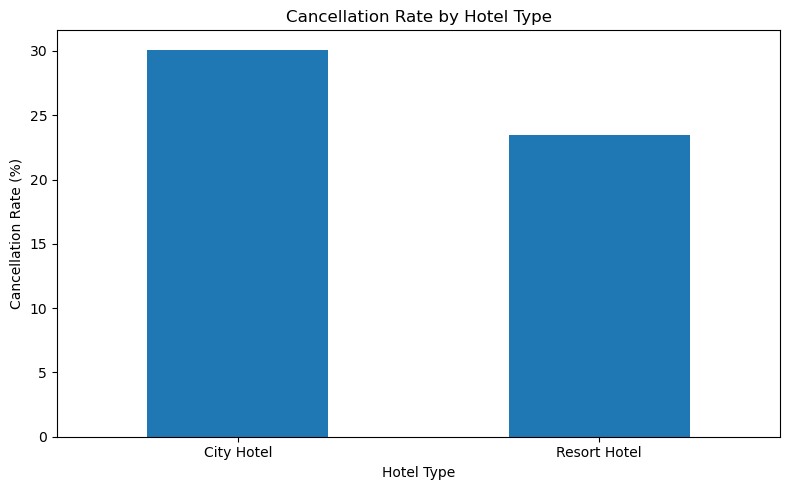

In [42]:
cancel_by_hotel = df_clean.groupby("hotel")["is_canceled"].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(8,5))
cancel_by_hotel.plot(kind="bar")
plt.title("Cancellation Rate by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Insight
City Hotel has a noticeably higher cancellation rate than Resort Hotel. This suggests that bookings in city hotels may be more flexible or more sensitive to changes in customer plans, while resort bookings appear relatively more stable.

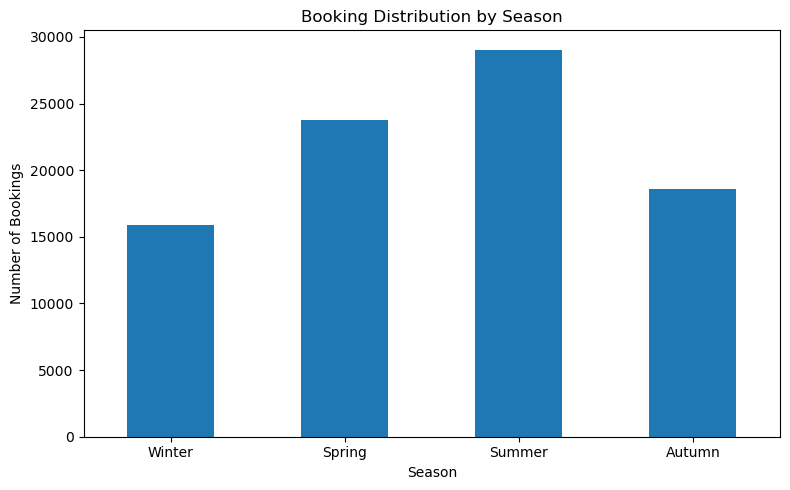

In [43]:
season_counts = df_clean["season"].value_counts().reindex(["Winter", "Spring", "Summer", "Autumn"])

plt.figure(figsize=(8,5))
season_counts.plot(kind="bar")
plt.title("Booking Distribution by Season")
plt.xlabel("Season")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Insight
Summer has the highest number of bookings, while winter has the lowest in this dataset. This pattern suggests seasonal variation in booking demand, although the results should be interpreted within the time coverage of the available data.

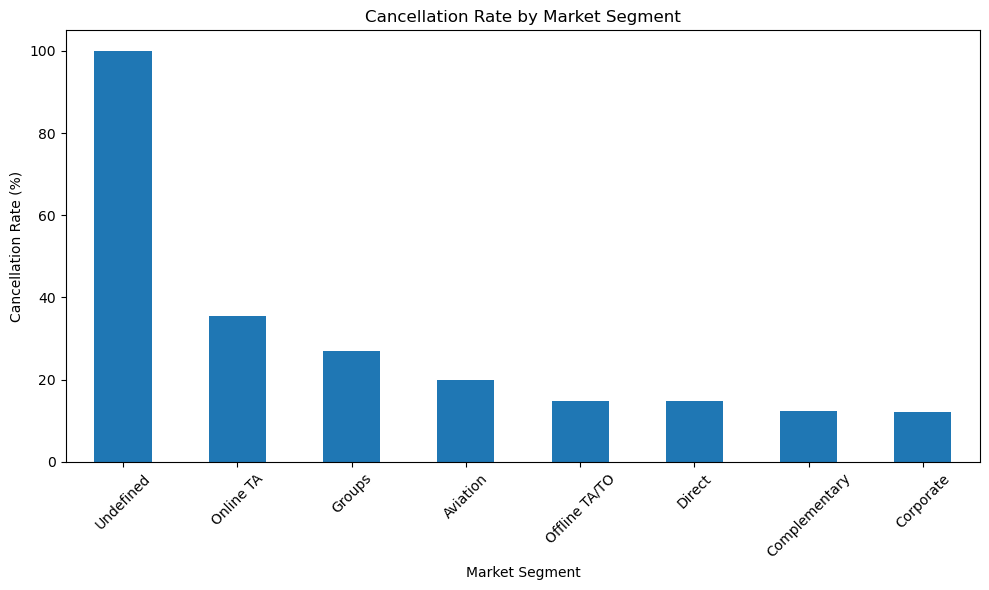

In [44]:
cancel_by_segment = (
    df_clean.groupby("market_segment")["is_canceled"]
    .mean()
    .sort_values(ascending=False) * 100
)

plt.figure(figsize=(10,6))
cancel_by_segment.plot(kind="bar")
plt.title("Cancellation Rate by Market Segment")
plt.xlabel("Market Segment")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight
Cancellation behavior differs notably across market segments. While the `Undefined` segment shows the highest cancellation rate, this category should be interpreted with caution and validated against its booking volume. Among the major segments, `Online TA` appears to have a relatively high cancellation rate, whereas `Corporate` and `Complementary` show lower cancellation levels.

In [45]:
segment_summary = df_clean.groupby("market_segment").agg(
    booking_count=("market_segment", "count"),
    cancellation_rate=("is_canceled", "mean")
)

segment_summary["cancellation_rate"] = segment_summary["cancellation_rate"] * 100
segment_summary.sort_values(by="cancellation_rate", ascending=False)

,booking_count,cancellation_rate
market_segment,,
Undefined,2,100.000000
Online TA,51550,35.387003
Groups,4921,27.067669
Aviation,226,19.911504
Offline TA/TO,13855,14.846626
Direct,11780,14.745331
Complementary,692,12.283237
Corporate,4196,12.130601


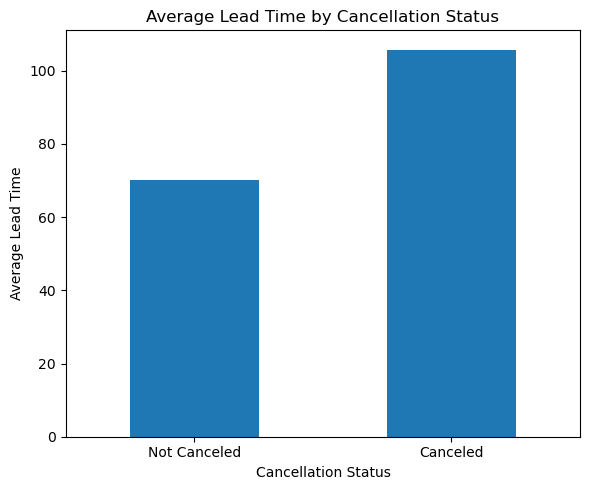

In [46]:
leadtime_cancel = df_clean.groupby("is_canceled")["lead_time"].mean()
leadtime_cancel.index = ["Not Canceled", "Canceled"]

plt.figure(figsize=(6, 5))
leadtime_cancel.plot(kind="bar")
plt.title("Average Lead Time by Cancellation Status")
plt.xlabel("Cancellation Status")
plt.ylabel("Average Lead Time")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Insight
Canceled bookings have a noticeably higher average lead time than non-canceled bookings. This suggests that reservations made further in advance are more likely to be canceled, possibly because travelers have more time to change or cancel their plans.

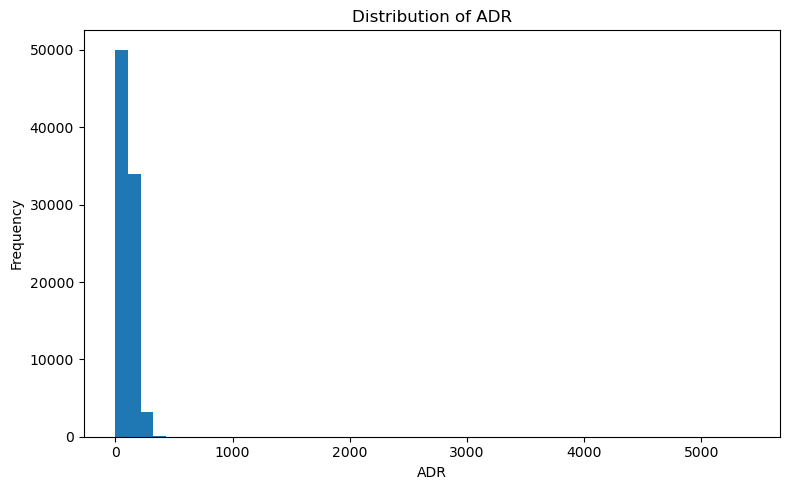

In [47]:
plt.figure(figsize=(8,5))
plt.hist(df_clean["adr"], bins=50)
plt.title("Distribution of ADR")
plt.xlabel("ADR")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

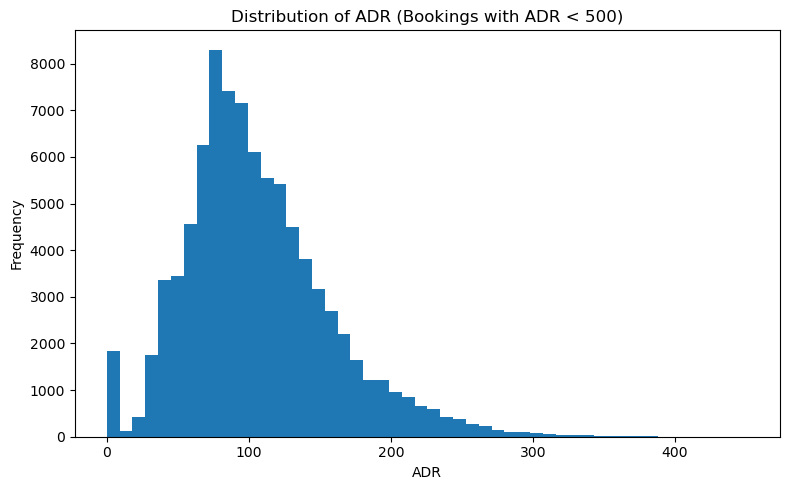

In [48]:
plt.figure(figsize=(8,5))
plt.hist(df_clean[df_clean["adr"] < 500]["adr"], bins=50)
plt.title("Distribution of ADR (Bookings with ADR < 500)")
plt.xlabel("ADR")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Insight
The ADR distribution is right-skewed, with most bookings concentrated in the lower-to-mid price range and a gradual tail extending toward higher values. This indicates that while most reservations fall within a moderate pricing band, a smaller number of bookings have substantially higher daily rates.

## 10. Key Insights

- City Hotel showed a higher cancellation rate than Resort Hotel, suggesting less stable booking behavior.
- Booking demand showed a seasonal pattern, with the highest volume in summer and the lowest in winter.
- Cancellation patterns differed across market segments. While `Undefined` showed a 100% cancellation rate, it only contained two bookings and was therefore not considered a meaningful pattern.
- `Online TA` emerged as one of the most important market segments due to its high booking volume and relatively high cancellation rate.
- Canceled bookings had a longer average lead time than non-canceled bookings, indicating that reservations made further in advance were more likely to be canceled.
- ADR values were concentrated mostly in the lower-to-mid price range, with a right-skewed distribution and a small number of high-value bookings.

## 11. Conclusion

The dataset was cleaned, validated, and analyzed to better understand hotel booking behavior. The findings show that cancellation behavior varies by hotel type, market segment, and booking lead time, while booking demand also changes significantly across seasons. These insights can support better forecasting, pricing decisions, and operational planning in the hospitality industry.

In [49]:
df_clean.to_csv( "../data/processed/hotel_bookings_cleaned.csv", index=False)

In [50]:
print("File saved:", os.path.exists("../data/processed/hotel_bookings_cleaned.csv"))

File saved: True
